# MuJoCo Simulation Demo - Dobot CR5 Surgical Robot

**Phase A: Model Preparation Results**

This notebook demonstrates the MuJoCo simulation of the Dobot CR5 surgical robot
with DH-3 gripper and 4 surgical instruments.

| Component | Status |
|-----------|--------|
| CR5 MJCF model (from official URDF) | Loaded from STL meshes |
| DH-3 parallel gripper | 2-finger, slide joints |
| 4 surgical instruments | Scalpel, tweezers, scissors, needle holder |
| Complete scene | Table + tray + delivery marker |

> Run all cells in order. First cell installs dependencies (~30s).


In [1]:
# Cell 1: Install dependencies
!pip install -q mujoco mediapy numpy matplotlib

import sys
print(f"Python {sys.version}")
import mujoco; print(f"MuJoCo {mujoco.__version__}")
import mediapy; print("mediapy OK")
import numpy as np; print(f"NumPy {np.__version__}")


Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
MuJoCo 3.6.0
mediapy OK
NumPy 2.0.2


In [2]:
# Cell 2: Clone repository and load model
import os, shutil

REPO = "https://github.com/Zebedee2021/surgbot-docs.git"
LOCAL = "/content/surgbot-docs"

if os.path.exists(LOCAL):
    shutil.rmtree(LOCAL)

!git clone --depth 1 -q {REPO} {LOCAL}

SCENE_PATH = os.path.join(LOCAL, "models", "scene", "surgbot_scene.xml")
CR5_PATH = os.path.join(LOCAL, "models", "cr5", "cr5_robot.xml")

# Load scene
os.chdir(os.path.dirname(SCENE_PATH))
model = mujoco.MjModel.from_xml_path(os.path.basename(SCENE_PATH))
data = mujoco.MjData(model)

print(f"Scene loaded!")
print(f"  Bodies:    {model.nbody}")
print(f"  Joints:    {model.njnt}")
print(f"  Actuators: {model.nu}")
print(f"  Sensors:   {model.nsensor}")
print(f"  Keyframes: {model.nkey}")
print(f"  Total mass: {sum(model.body_mass):.1f} kg")


Scene loaded!
  Bodies:    20
  Joints:    12
  Actuators: 8
  Sensors:   4
  Keyframes: 3
  Total mass: 41.4 kg


In [3]:
# Cell 3: Rendering helpers
import math

# Install pyvirtualdisplay and setup a virtual display for headless environments
!pip install -q pyvirtualdisplay
from pyvirtualdisplay import Display
display = Display(visible=0, size=(1400, 900))
display.start()

renderer = mujoco.Renderer(model, height=480, width=640) # Adjusted height to 480

def render_frame(data, camera_name=None, elevation=-25, azimuth=135, distance=2.0, lookat=None):
    """Render a single frame with specified camera parameters."""
    if lookat is None:
        lookat = [0.2, 0, 0.8]
    renderer.update_scene(data, mujoco.MjvCamera())
    # Update camera
    cam = renderer.scene.camera[0]
    scene = renderer.scene
    # Use free camera
    mujoco.mjv_updateScene(
        model, data, mujoco.MjvOption(), None,
        mujoco.MjvCamera(), mujoco.mjtCatBit.mjCAT_ALL.value, scene)
    # Configure camera
    scene_cam = mujoco.MjvCamera()
    scene_cam.type = mujoco.mjtCamera.mjCAMERA_FREE
    scene_cam.lookat[:] = lookat
    scene_cam.distance = distance
    scene_cam.elevation = elevation
    scene_cam.azimuth = azimuth
    renderer.update_scene(data, scene_cam)
    return renderer.render()

# Degree to radian shortcut
def deg2rad(degrees):
    return [math.radians(d) for d in degrees]

# Known poses
RESET_RAD = deg2rad([0, 32.6, -129.1, 6.7, 90, -90])
TARGET_RAD = deg2rad([0, -50.2, -67.3, 112.5, 90, -90])

print("Renderer ready: 640x480") # Updated print statement to reflect new height


Renderer ready: 640x480


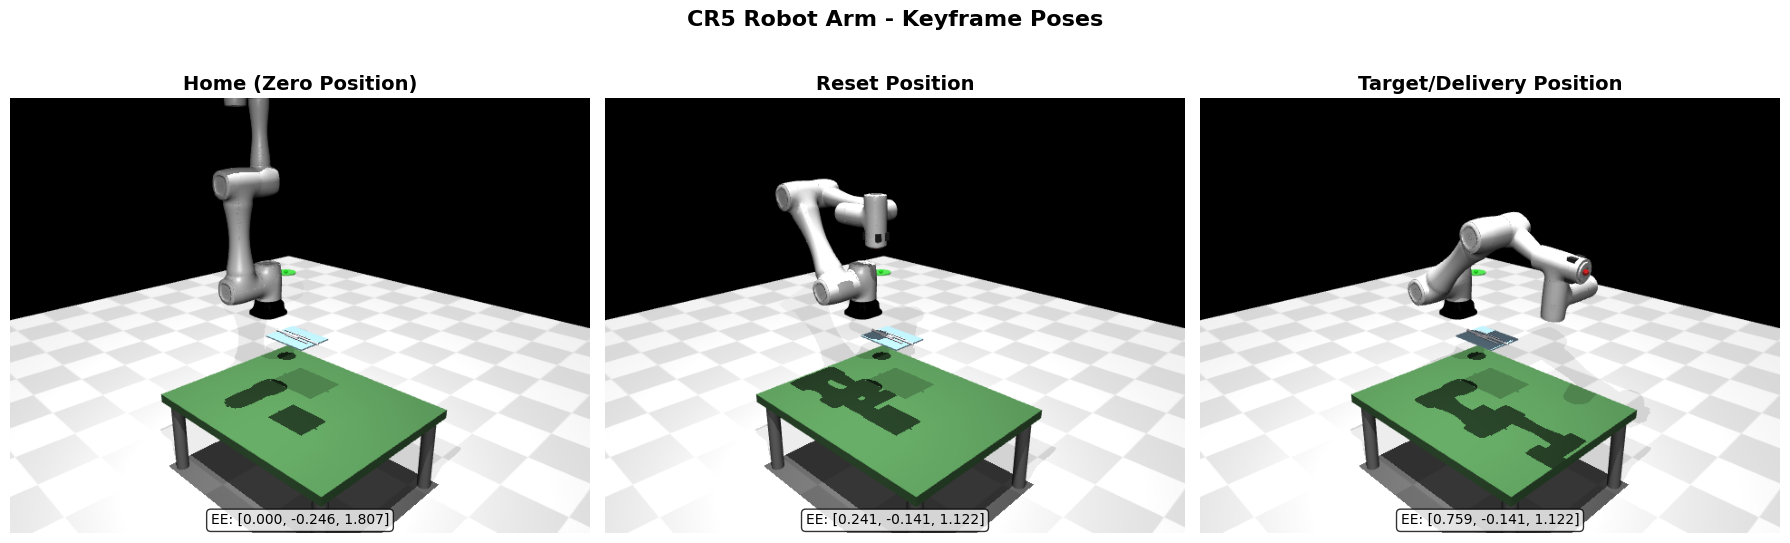

In [4]:
# Cell 4: Render all keyframes - gallery view
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
keyframe_names = ['home', 'reset', 'target']
titles = ['Home (Zero Position)', 'Reset Position', 'Target/Delivery Position']

for idx, (kname, title) in enumerate(zip(keyframe_names, titles)):
    key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, kname)
    data.qpos[:] = model.key_qpos[key_id]
    data.ctrl[:] = model.key_ctrl[key_id]
    mujoco.mj_forward(model, data)

    frame = render_frame(data, distance=2.2, elevation=-20, azimuth=135)
    axes[idx].imshow(frame)
    axes[idx].set_title(title, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

    # Print EE position
    ee_id = model.site("ee_site").id
    ee = data.site_xpos[ee_id]
    axes[idx].text(0.5, 0.02, f"EE: [{ee[0]:.3f}, {ee[1]:.3f}, {ee[2]:.3f}]",
                   transform=axes[idx].transAxes, ha='center', fontsize=10,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('CR5 Robot Arm - Keyframe Poses', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


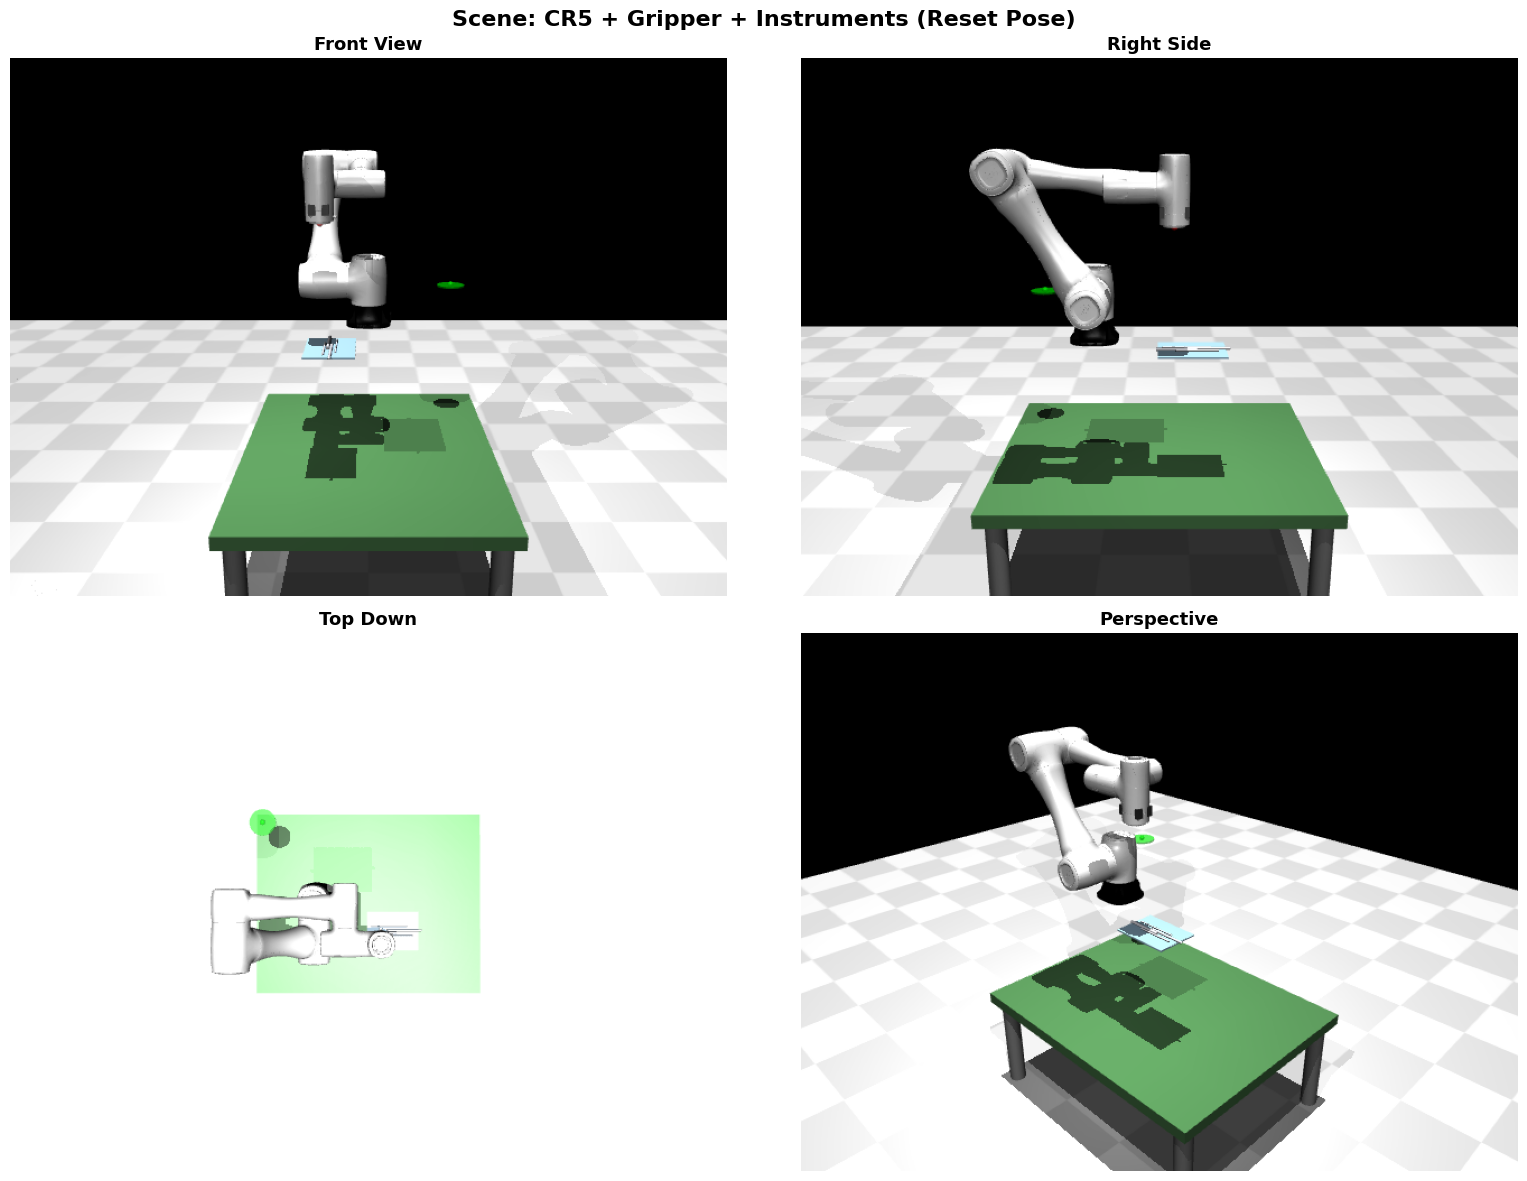

In [5]:
# Cell 5: Multi-angle view of the scene (reset pose)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Set to reset pose
key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, 'reset')
data.qpos[:] = model.key_qpos[key_id]
data.ctrl[:] = model.key_ctrl[key_id]
mujoco.mj_forward(model, data)

views = [
    ("Front View",   -15, 180, 2.0),
    ("Right Side",   -15, 90,  2.0),
    ("Top Down",     -89, 90,  2.5),
    ("Perspective",  -25, 135, 2.2),
]

for idx, (title, elev, azim, dist) in enumerate(views):
    r, c = divmod(idx, 2)
    frame = render_frame(data, elevation=elev, azimuth=azim, distance=dist)
    axes[r][c].imshow(frame)
    axes[r][c].set_title(title, fontsize=13, fontweight='bold')
    axes[r][c].axis('off')

plt.suptitle('Scene: CR5 + Gripper + Instruments (Reset Pose)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


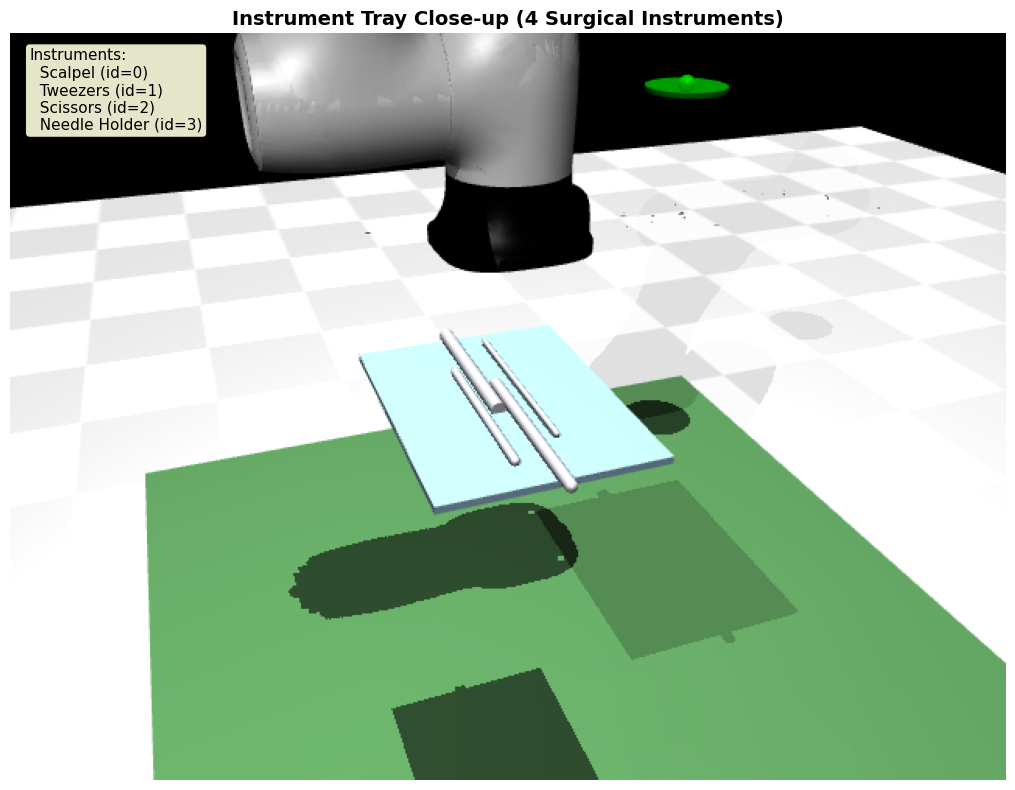

In [6]:
# Cell 6: Close-up of instrument tray
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Set to home (instruments visible)
key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, 'home')
data.qpos[:] = model.key_qpos[key_id]
mujoco.mj_forward(model, data)

frame = render_frame(data, distance=0.6, elevation=-30, azimuth=160,
                     lookat=[0.3, -0.11, 0.76])
ax.imshow(frame)
ax.set_title('Instrument Tray Close-up (4 Surgical Instruments)', fontsize=14, fontweight='bold')
ax.axis('off')

# Label instruments
instruments = {
    'Scalpel': 'scalpel_handle',
    'Tweezers': 'tweezers',
    'Scissors': 'scissors',
    'Needle Holder': 'needle_holder',
}
info_text = "\n".join([f"  {name} (id={i})" for i, name in enumerate(instruments.keys())])
ax.text(0.02, 0.98, f"Instruments:\n{info_text}",
        transform=ax.transAxes, va='top', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()


In [8]:
# Cell 7: Animate joint motion (Reset -> Target pose)
frames = []
n_steps = 150
fps = 30

# Start from reset pose
key_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, 'reset')
data.qpos[:] = model.key_qpos[key_id]
data.ctrl[:] = model.key_ctrl[key_id]
mujoco.mj_forward(model, data)

# Linear interpolation from reset to target
for step in range(n_steps):
    t = step / (n_steps - 1)
    for i in range(6):
        data.ctrl[i] = RESET_RAD[i] * (1 - t) + TARGET_RAD[i] * t
    # Keep gripper open
    data.ctrl[6] = 0.02
    data.ctrl[7] = 0.02
    # Step simulation
    for _ in range(10):
        mujoco.mj_step(model, data)
    # Render every 3rd step
    if step % 3 == 0:
        frames.append(render_frame(data, distance=2.2, elevation=-20, azimuth=135))

print(f"Captured {len(frames)} frames")
mediapy.show_video(frames, fps=fps, title="Reset -> Target Motion")

Captured 50 frames


Reset -> Target Motion This browser does not support the video tag.


In [11]:
# Cell 8: Gripper open/close cycle animation
frames_g = []

# Move to reset pose first
for i in range(6):
    data.ctrl[i] = RESET_RAD[i]
for _ in range(500):
    mujoco.mj_step(model, data)

# Open -> Close -> Open cycle
gripper_targets = (
    [(0.025, "Opening")] * 40 +
    [(0.0, "Closing")] * 40 +
    [(0.025, "Opening")] * 40
)

for step, (g_target, label) in enumerate(gripper_targets):
    data.ctrl[6] = g_target
    data.ctrl[7] = g_target
    for _ in range(5):
        mujoco.mj_step(model, data)
    if step % 2 == 0:
        frames_g.append(render_frame(data, distance=0.4, elevation=-10,
                                     azimuth=135, lookat=list(data.site_xpos[model.site("gripper_tcp").id])))

print(f"Captured {len(frames_g)} frames")
mediapy.show_video(frames_g, fps=20, title="Gripper Open/Close Cycle")


Captured 60 frames


Gripper Open/Close Cycle This browser does not support the video tag.


In [12]:
# Cell 9: Complete model summary
print("=" * 60)
print("SURGBOT MuJoCo MODEL SUMMARY")
print("=" * 60)

print(f"\nRobot: Dobot CR5AF (6-DOF collaborative arm)")
print(f"Gripper: DH-3 (2-finger parallel, slide joints)")
print(f"Instruments: 4 surgical tools on tray")

print(f"\n--- Model Statistics ---")
print(f"Bodies:     {model.nbody}")
print(f"Joints:     {model.njnt} (6 arm + 2 gripper + 4 free)")
print(f"Geoms:      {model.ngeom}")
print(f"Actuators:  {model.nu} (6 arm + 2 gripper)")
print(f"Sensors:    {model.nsensor} (force, torque, 2x touch)")
print(f"Keyframes:  {model.nkey} (home, reset, target)")
print(f"Total mass: {sum(model.body_mass):.1f} kg")

print(f"\n--- Joint Ranges ---")
for i in range(model.njnt):
    jname = model.joint(i).name
    jtype = {0: "free", 1: "ball", 2: "slide", 3: "hinge"}[model.jnt_type[i]]
    if jtype == "hinge":
        lo, hi = model.jnt_range[i]
        print(f"  {jname:20s} [{math.degrees(lo):7.1f}, {math.degrees(hi):7.1f}] deg")
    elif jtype == "slide":
        lo, hi = model.jnt_range[i]
        print(f"  {jname:20s} [{lo*1000:7.1f}, {hi*1000:7.1f}] mm")
    else:
        print(f"  {jname:20s} ({jtype})")

print(f"\n--- End-Effector Positions ---")
for kname in ['home', 'reset', 'target']:
    kid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_KEY, kname)
    data.qpos[:] = model.key_qpos[kid]
    mujoco.mj_forward(model, data)
    ee = data.site_xpos[model.site("ee_site").id]
    print(f"  {kname:8s}: [{ee[0]:.3f}, {ee[1]:.3f}, {ee[2]:.3f}] m")

print(f"\n--- Phase A Status ---")
print(f"  CR5 URDF -> MJCF conversion:  DONE")
print(f"  DH-3 gripper model:           DONE")
print(f"  Instrument models (4):        DONE")
print(f"  Scene assembly:               DONE")
print(f"  Colab demo:                   DONE")
print(f"\nReady for Phase B (control logic) and Phase C (Colab integration)")
print("=" * 60)


SURGBOT MuJoCo MODEL SUMMARY

Robot: Dobot CR5AF (6-DOF collaborative arm)
Gripper: DH-3 (2-finger parallel, slide joints)
Instruments: 4 surgical tools on tray

--- Model Statistics ---
Bodies:     20
Joints:     12 (6 arm + 2 gripper + 4 free)
Geoms:      24
Actuators:  8 (6 arm + 2 gripper)
Sensors:    4 (force, torque, 2x touch)
Keyframes:  3 (home, reset, target)
Total mass: 41.4 kg

--- Joint Ranges ---
  joint1               [ -179.9,   179.9] deg
  joint2               [ -179.9,   179.9] deg
  joint3               [ -163.9,   163.9] deg
  joint4               [ -179.9,   179.9] deg
  joint5               [ -179.9,   179.9] deg
  joint6               [ -359.8,   359.8] deg
  gripper_left         [    0.0,    25.0] mm
  gripper_right        [    0.0,    25.0] mm
  scalpel_free         (free)
  tweezers_free        (free)
  scissors_free        (free)
  needle_holder_free   (free)

--- End-Effector Positions ---
  home    : [0.000, -0.246, 1.807] m
  reset   : [0.241, -0.141, 1.12